In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

### Load Dataset

In [2]:
from tensorflow.keras.datasets import cifar10

In [3]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170508288/170498071 [==============================] - 6s 0us/step


In [4]:
print(X_train.shape, y_train.shape)

(50000, 32, 32, 3) (50000, 1)


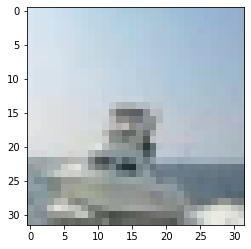

In [5]:
import matplotlib.pyplot as plt
plt.imshow(X_train[100])

## Data Preprocessing

In [6]:
from tensorflow.keras.utils import to_categorical

y_test = to_categorical(y_test)
y_train = to_categorical(y_train)

In [7]:
X_train = X_train/255
X_test = X_test/255

X_train.shape

(50000, 32, 32, 3)

### Prepare Model

In [8]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, MaxPooling2D, Conv2D

cnn_model = Sequential()

2022-07-26 15:50:34.761740: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-07-26 15:50:34.917303: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-07-26 15:50:34.918411: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-07-26 15:50:34.920733: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags

In [9]:
cnn_model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same', input_shape=(32, 32, 3)))
cnn_model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
cnn_model.add(MaxPooling2D((2, 2)))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
cnn_model.add(Dense(10, activation='softmax'))

# compile model
from tensorflow.keras.optimizers import SGD
opt = SGD(learning_rate=0.001, momentum=0.9)
cnn_model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

In [10]:
hist = cnn_model.fit(batch_size=32, epochs=18, x=X_train, y=y_train, validation_split=0.2)

2022-07-26 15:50:40.421837: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/18


2022-07-26 15:50:42.079257: I tensorflow/stream_executor/cuda/cuda_dnn.cc:369] Loaded cuDNN version 8005


1250/1250 [==============================] - 15s 5ms/step - loss: 1.7637 - accuracy: 0.3691 - val_loss: 1.5166 - val_accuracy: 0.4627
Epoch 2/18
1250/1250 [==============================] - 5s 4ms/step - loss: 1.4031 - accuracy: 0.4994 - val_loss: 1.3489 - val_accuracy: 0.5242
Epoch 3/18
1250/1250 [==============================] - 6s 5ms/step - loss: 1.2494 - accuracy: 0.5556 - val_loss: 1.2585 - val_accuracy: 0.5575
Epoch 4/18
1250/1250 [==============================] - 5s 4ms/step - loss: 1.1358 - accuracy: 0.5986 - val_loss: 1.1887 - val_accuracy: 0.5855
Epoch 5/18
1250/1250 [==============================] - 6s 5ms/step - loss: 1.0384 - accuracy: 0.6361 - val_loss: 1.1086 - val_accuracy: 0.6158
Epoch 6/18
1250/1250 [==============================] - 5s 4ms/step - loss: 0.9552 - accuracy: 0.6679 - val_loss: 1.1042 - val_accuracy: 0.6205
Epoch 7/18
1250/1250 [==============================] - 7s 5ms/step - loss: 0.8765 - accuracy: 0.6963 - val_loss: 1.0547 - val_accuracy: 0.6345
Ep

In [11]:
predict_x = cnn_model.predict(X_test) 
classes_x = np.argmax(predict_x,axis=1)

classes_x

array([5, 8, 0, ..., 5, 4, 7])

In [12]:
class_map = ['airplane',
'automobile',
'bird',
'cat',
'deer',
'dog',
'frog',
'horse',
'ship',
'truck']


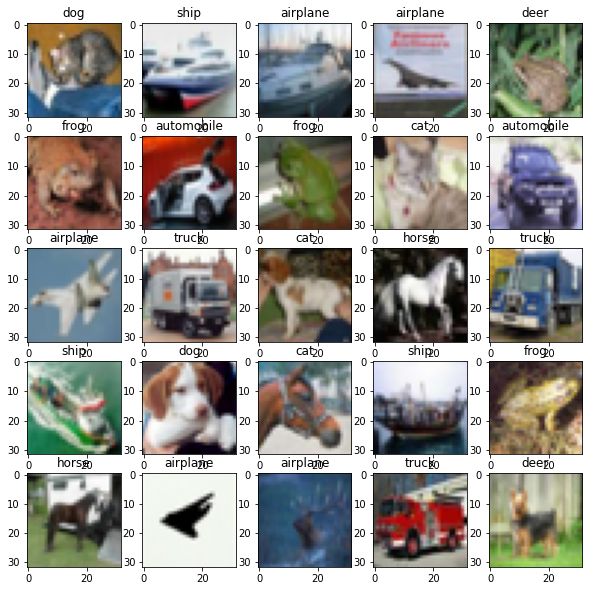

In [13]:
num_display = 0

axes, fig = plt.subplots(5,5,figsize=(10, 10))

for i in range(5):
    for j in range(5):
        fig[i,j].imshow(X_test[num_display])
        fig[i,j].set_title(class_map[classes_x[num_display]])
        num_display += 1